# Notebook 2: Hypothesis Testing
---

### Why this matters
Hypothesis testing is how you make **data-driven decisions with confidence**. You'll use this for:
- **A/B testing** — did the new model/feature actually improve things?
- **Feature selection** — is this feature statistically related to the target?
- **Model comparison** — is Model A genuinely better than Model B, or just luck?
- **Data drift detection** — has my production data distribution shifted?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_theme(style='whitegrid')

| Library | Role |
|---------|------|
| NumPy | Raw math — arrays, mean, std, percentiles |
| Pandas | Data wrangling — DataFrames, groupby, missing values |
| Matplotlib / Seaborn | Visualization |
| SciPy | Statistical tests — hypothesis testing, distributions, QQ plots |

## 1. The Core Idea: Null vs Alternative Hypothesis

Every hypothesis test follows the same logic:

1. **H₀ (Null):** Nothing changed / no difference / no relationship
2. **H₁ (Alternative):** Something changed / there is a difference
3. You collect data and calculate: *how likely is this data if H₀ were true?*
4. That probability is the **p-value**

---

### The p-value (most misunderstood concept in statistics)

> **p-value = probability of seeing your data (or more extreme) if the null hypothesis were true**

- **p < 0.05** → your data is unlikely under H₀ → reject H₀ → result is "statistically significant"
- **p ≥ 0.05** → not enough evidence to reject H₀

**Common mistake:** p-value is NOT the probability that H₀ is true. It doesn't measure effect size either — a tiny useless difference can be "significant" with enough data.

**Significance level (α = 0.05):** The threshold you set *before* the test. Industry standard is 5%.

## Hypothesis Testing & p-value

Let me use a simple example throughout: you're testing whether a new ML model is actually better than the old one.

**H₀ (Null Hypothesis) = "nothing is going on"**
You start by assuming the boring answer is true:
"The new model is NOT better. Any difference I see is just random chance."
You always start here. It's the default assumption you're trying to disprove.

**H₁ (Alternative Hypothesis) = "something is going on"**
What you're trying to prove:
"The new model IS actually better."

---

**p-value = how embarrassing your data would be if H₀ were true**

Imagine H₀ is true — the new model is NOT better. Now you run a test and see Model B scores 4% higher. The p-value asks:
> *"If the models are truly equal, how often would I randomly see a 4% gap just by luck?"*

* p = 0.80 → this gap happens 80% of the time by luck → keep H₀
* p = 0.03 → this gap only happens 3% of the time by luck → reject H₀ → Model B is genuinely better

**α = 0.05 = where you draw the line**
You decide upfront: "I'll only believe the result if it would happen less than 5% of the time by luck."
That's it. 0.05 is just the industry agreed-upon threshold. You could use 0.01 if you want to be stricter.

---

**Still confused? The courtroom analogy:**

In court, the defendant is innocent until proven guilty.

* H₀ = innocent (default assumption)
* H₁ = guilty (what you're trying to prove)

The p-value is like asking:
> *"If this person is truly innocent, how likely is it that all this evidence against them showed up by coincidence?"*

* p = 0.80 → evidence could easily show up by coincidence → not enough to convict → innocent
* p = 0.03 → evidence is very unlikely to be a coincidence → convict → guilty

The 0.05 threshold is like the jury's standard of "beyond reasonable doubt."

---

**Back to the model example:**

You test Model A vs Model B. Model B scores 4% higher.
p-value asks one question:
> *"If both models are truly equal, how often would I randomly get a 4% gap just from the randomness of my test data?"*

* p = 0.70 → 70% of the time you'd see this gap even if models are equal → gap is just noise → models are the same
* p = 0.03 → only 3% of the time you'd see this gap if models are equal → too unlikely to be noise → Model B is genuinely better

---

**The common mistake:**

p = 0.03 does **NOT** mean "there's a 97% chance H₀ is false."
It means: *"if H₀ were true, I'd only see this data 3% of the time."* Subtle but important difference.

**One line summary:**
p-value = the probability that your result is just luck.
Small p → not luck → real difference → reject H₀

## 2. One-Sample t-Test

**Question:** Is the mean of my sample different from a known value?

**Example:** A model claims average prediction error is 10ms. We measure 50 responses. Is the actual mean really 10ms?

**When to use:** One group, comparing against a known/claimed value. Data should be roughly normal.

In [3]:
# Scenario: API response times — claimed average is 200ms
claimed_mean = 200
response_times = np.random.normal(loc=215, scale=30, size=50)  # actual avg is 215ms

t_stat, p_value = stats.ttest_1samp(response_times, popmean=claimed_mean)

print("=== One-Sample t-Test ===")
print(f"H₀: mean response time = {claimed_mean}ms")
print(f"H₁: mean response time ≠ {claimed_mean}ms")
print(f"\nSample mean: {response_times.mean():.1f}ms")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.4f}")
print()
if p_value < 0.05:
    print("→ Reject H₀: response time is significantly different from 200ms")
else:
    print("→ Fail to reject H₀: not enough evidence")

=== One-Sample t-Test ===
H₀: mean response time = 200ms
H₁: mean response time ≠ 200ms

Sample mean: 208.2ms
t-statistic: 2.079
p-value:     0.0429

→ Reject H₀: response time is significantly different from 200ms


## 3. Two-Sample t-Test (Independent)

**Question:** Are the means of two independent groups different?

**Example (A/B test):** Model A vs Model B — which has lower latency? Did the new recommendation algorithm increase engagement?

**When to use:** Two separate groups, comparing their means. This is the backbone of A/B testing.

=== Two-Sample t-Test (A/B Test) ===
Model A mean accuracy: 0.8230
Model B mean accuracy: 0.8601
t-statistic: -3.523
p-value:     0.0007

→ Reject H₀: Model B is significantly better (p=0.0007)


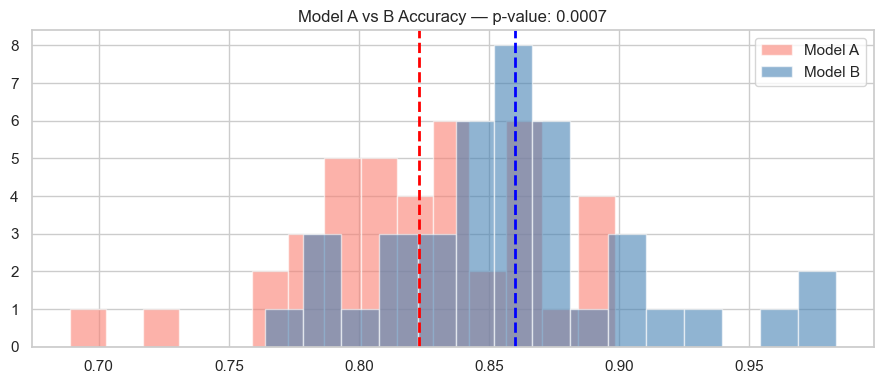

In [4]:
# A/B test: old model vs new model accuracy scores
model_a_scores = np.random.normal(loc=0.82, scale=0.05, size=40)  # old model
model_b_scores = np.random.normal(loc=0.86, scale=0.05, size=40)  # new model

t_stat, p_value = stats.ttest_ind(model_a_scores, model_b_scores)

print("=== Two-Sample t-Test (A/B Test) ===")
print(f"Model A mean accuracy: {model_a_scores.mean():.4f}")
print(f"Model B mean accuracy: {model_b_scores.mean():.4f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.4f}")
print()
if p_value < 0.05:
    better = 'B' if model_b_scores.mean() > model_a_scores.mean() else 'A'
    print(f"→ Reject H₀: Model {better} is significantly better (p={p_value:.4f})")
else:
    print("→ Fail to reject H₀: difference could be random chance")

# Visualize
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(model_a_scores, bins=15, alpha=0.6, label='Model A', color='salmon')
ax.hist(model_b_scores, bins=15, alpha=0.6, label='Model B', color='steelblue')
ax.axvline(model_a_scores.mean(), color='red', linestyle='--', linewidth=2)
ax.axvline(model_b_scores.mean(), color='blue', linestyle='--', linewidth=2)
ax.set_title(f'Model A vs B Accuracy — p-value: {p_value:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Chi-Squared Test

**Question:** Is there a relationship between two **categorical** variables?

**Example:** Does user device type (mobile/desktop) affect conversion rate? Is a categorical feature independent of the target label?

**When to use:** Both variables are categorical. Very common in feature selection for classification problems.

In [5]:
# Does device type affect purchase rate?
# Observed counts: [purchased, not purchased] for [mobile, desktop]
observed = np.array([
    [120, 380],   # mobile: 120 purchased, 380 didn't
    [200, 300],   # desktop: 200 purchased, 300 didn't
])

chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed)

print("=== Chi-Squared Test ===")
print("H₀: device type and purchase are independent (no relationship)")
print("H₁: there is a relationship between device type and purchase")
print(f"\nMobile conversion rate:  {observed[0,0] / observed[0].sum():.1%}")
print(f"Desktop conversion rate: {observed[1,0] / observed[1].sum():.1%}")
print(f"\nChi² statistic: {chi2_stat:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4f}")
print()
if p_value < 0.05:
    print("→ Reject H₀: device type significantly affects purchase rate")
else:
    print("→ Fail to reject H₀: no significant relationship found")

=== Chi-Squared Test ===
H₀: device type and purchase are independent (no relationship)
H₁: there is a relationship between device type and purchase

Mobile conversion rate:  24.0%
Desktop conversion rate: 40.0%

Chi² statistic: 28.681
Degrees of freedom: 1
p-value: 0.0000

→ Reject H₀: device type significantly affects purchase rate


## 5. When to Use Which Test

| Situation | Test | Example |
|-----------|------|---------|
| 1 group vs known value | One-sample t-test | Is avg latency = 100ms? |
| 2 independent groups | Two-sample t-test | Model A vs Model B |
| Before/after same group | Paired t-test | User scores before vs after feature change |
| 3+ groups | ANOVA | Compare 3 model versions |
| 2 categorical variables | Chi-squared | Device type vs purchase? |
| Data is NOT normal, small n | Mann-Whitney U | Non-parametric alternative to 2-sample t-test |

---

### Quick checklist before running a test:
1. Is my data normal? (Check with QQ plot or Shapiro-Wilk)
2. Are the groups independent or paired?
3. Are the variables numeric or categorical?
4. Set your α threshold **before** looking at the data (usually 0.05)

## 6. Statistical vs Practical Significance

**A result can be statistically significant but practically useless.**

p-value only tells you **"is this real or luck?"** — it says nothing about how big the difference actually is.

> With 1 million users, even a 0.001% improvement gives p < 0.05 — statistically real, but would you spend 3 months of engineering work for 0.001%? No.

So you always need two checks:
1. **p-value** → is it real or luck?
2. **Effect size** → is it big enough to care about?

---

### Cohen's d — how big is the difference?

Measures the gap between two groups in standard deviation units.

| Value | Meaning | Real world |
|-------|---------|------------|
| 0.2 | Small | Hard to notice |
| 0.5 | Medium | Noticeable |
| 0.8 | Large | Obviously different |

From the Model A vs B example:
- `Cohen's d = 0.798 → medium effect`
- Model B outperforms Model A by 0.80 standard deviations
- p = 0.0007 (real) + d = 0.798 (meaningful size) → **worth shipping**

---

### Confidence Interval — the range, not just yes/no

Instead of just saying "Model B is better by 0.037", a 95% CI gives you a range you can trust:

> *"We're 95% confident the true difference is somewhere between 0.016 and 0.058"*

**The key rule — look at whether 0 is inside the range:**

- CI **excludes 0** → difference is real → significant
  - e.g. `[0.0164, 0.0579]` → zero is not in here → Model B is genuinely better ✓

- CI **includes 0** → true difference could be zero → not significant
  - e.g. `[-0.012, 0.051]` → zero is inside → models could actually be equal ✗

If zero is inside the range, it means the models could actually be equal — you can't confidently say one is better, even if the means look different.

---

### Always report all three together:

| | Tells you |
|-|----------|
| p-value | Real or luck? |
| Cohen's d | How big is the difference? |
| Confidence interval | What's the plausible range? |

In [6]:
# Cohen's d — effect size for two-sample t-test
def cohens_d(group1, group2):
    pooled_std = np.sqrt((np.std(group1)**2 + np.std(group2)**2) / 2)
    return (np.mean(group1) - np.mean(group2)) / pooled_std

d = cohens_d(model_b_scores, model_a_scores)
size_label = 'small' if abs(d) < 0.5 else ('medium' if abs(d) < 0.8 else 'large')

print(f"Cohen's d = {d:.3f} → {size_label} effect")
print(f"Model B outperforms Model A by {abs(d):.2f} standard deviations")

# 95% Confidence interval for mean difference
diff = model_b_scores.mean() - model_a_scores.mean()
se = np.sqrt(np.var(model_a_scores)/len(model_a_scores) + np.var(model_b_scores)/len(model_b_scores))
ci = stats.t.ppf(0.975, df=len(model_a_scores)+len(model_b_scores)-2) * se
print(f"\nMean difference: {diff:.4f}")
print(f"95% CI: [{diff-ci:.4f}, {diff+ci:.4f}]")
print("(CI doesn't include 0 → statistically significant at α=0.05)")

Cohen's d = 0.798 → medium effect
Model B outperforms Model A by 0.80 standard deviations

Mean difference: 0.0371
95% CI: [0.0164, 0.0579]
(CI doesn't include 0 → statistically significant at α=0.05)


## Key Takeaways

- **p-value** = probability of your data if H₀ were true — NOT the probability H₀ is true
- **p < 0.05** = reject H₀ (use 0.05 unless you have a reason to change it)
- **Two-sample t-test** = your main tool for A/B testing
- **Chi-squared** = use when both variables are categorical
- Always check **effect size** alongside p-value — significance ≠ importance
- Set your threshold **before** collecting data, not after (p-hacking)

## Practice

**1.** You A/B test two recommendation models. Model A CTR = 4.2%, Model B CTR = 4.5%, p = 0.31.
- Can you conclude Model B is better? Why or why not?
- What would you do next?  

=> No, you cannot conclude Model B is better. p = 0.31 means there's a 31% chance this gap showed up by random luck — way above 0.05. Not enough evidence to reject H₀.  
Next: collect more data (larger sample size), then retest. The difference might be real but you don't have enough data to detect it yet.

**2.** A colleague says: *"our p-value is 0.001, so the null hypothesis is 99.9% false."*
- What's wrong with this statement?  

=> p = 0.001 means "if H₀ were true, I'd see this data only 0.1% of the time." It does NOT mean H₀ is 99.9% false. Those are two completely different statements. The p-value says nothing about the probability of H₀ being true or false.

**3.** You want to know if user location (urban / suburban / rural) affects subscription rate (subscribed yes/no). 
- Which test do you use and why?  

=> Chi-squared test. Because both variables are categorical — location has 3 categories (urban/suburban/rural) and subscription is yes/no. Chi-squared is specifically for testing relationships between categorical variables.

**4.** You compare two models and get p = 0.03, Cohen's d = 0.08.
- Is this result useful? What does it mean in plain English?  

=> Statistically significant (p = 0.03 < 0.05) but practically useless. Cohen's d = 0.08 is tiny — well below the "small" threshold of 0.2. In plain English: yes the difference is real and not luck, but it's so tiny it's not worth acting on. Don't ship the new model for a difference this small.